<a href="https://colab.research.google.com/github/deekshdechamma/NLP/blob/main/NLP_mainproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This is the NLP Project Code

Install required libraries

In [1]:
!pip install -q kagglehub nltk scikit-learn pandas numpy matplotlib seaborn gradio

Import libraries


In [2]:
import os
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


Download the dataset using KaggleHub

In [3]:
import kagglehub

dataset_path = kagglehub.dataset_download(
    "lakshmi25npathi/imdb-dataset-of-50k-movie-reviews"
)

print("Dataset downloaded successfully!")
print("Dataset location:")
print(dataset_path)

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Dataset downloaded successfully!
Dataset location:
/kaggle/input/imdb-dataset-of-50k-movie-reviews



Find the CSV file

In [4]:
import glob

csv_files = glob.glob(dataset_path + "/**/*.csv", recursive=True)

print("CSV files found:")
for file in csv_files:
    print(file)

CSV files found:
/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv


Load the dataset

In [5]:
csv_file = csv_files[0]

df = pd.read_csv(csv_file)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (50000, 2)


View the dataset

In [6]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


Check dataset information

In [7]:
print("Dataset Information")
print("=" * 50)

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Dataset Information
Number of rows: 50000
Number of columns: 2

Column names:
['review', 'sentiment']

Data types:
review       object
sentiment    object
dtype: object


Check missing values

In [8]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
review       0
sentiment    0
dtype: int64


Check duplicate reviews

In [9]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 418


Remove duplicates

In [10]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:")
print(df.shape)

Dataset shape after removing duplicates:
(49582, 2)


Check sentiment distribution

In [11]:
print(df["sentiment"].value_counts())

sentiment
positive    24884
negative    24698
Name: count, dtype: int64


Visualize sentiment distribution

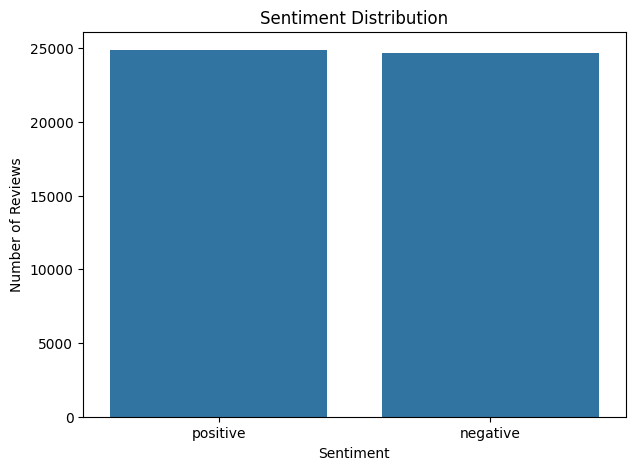

In [12]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="sentiment"
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

Convert sentiment into numbers

In [13]:
df["label"] = df["sentiment"].map({
    "negative": 0,
    "positive": 1
})

df.head()

,review,sentiment,label
0,One of the other reviewers has mentioned that ...,positive,1
1,A wonderful little production. <br /><br />The...,positive,1
2,I thought this was a wonderful way to spend ti...,positive,1
3,Basically there's a family where a little boy ...,negative,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1


Check label distribution

In [14]:
print(df["label"].value_counts())

label
1    24884
0    24698
Name: count, dtype: int64


Look at sample reviews

In [15]:
for i in range(5):
    print("Review:")
    print(df.iloc[i]["review"])
    print("Sentiment:", df.iloc[i]["sentiment"])
    print("-" * 100)

Review:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to

Download NLTK resources

In [16]:
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("wordnet")
nltk.download("omw-1.4")

print("NLTK resources downloaded successfully!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


NLTK resources downloaded successfully!


Create text preprocessing function

In [17]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def clean_text(text):
    # Convert to string
    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)

    # Keep only alphabets and spaces
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenization
    words = text.split()

    # Remove stopwords and lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

Test preprocessing

In [18]:
sample_text = """
This movie was absolutely AMAZING!
I really loved the acting and story.
"""

print("Original:")
print(sample_text)

print("\nCleaned:")
print(clean_text(sample_text))

Original:

This movie was absolutely AMAZING!
I really loved the acting and story.


Cleaned:
movie absolutely amazing really loved acting story


Clean the complete dataset

In [19]:
print("Cleaning reviews...")

df["cleaned_review"] = df["review"].apply(clean_text)

print("Text preprocessing completed!")

Cleaning reviews...
Text preprocessing completed!


Compare original and cleaned reviews

In [20]:
comparison = df[[
    "review",
    "cleaned_review",
    "sentiment"
]].head(5)

comparison

,review,cleaned_review,sentiment
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode hoo...,positive
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...,positive
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...,positive
3,Basically there's a family where a little boy ...,basically family little boy jake think zombie ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love time money visually stunnin...,positive


Remove empty reviews

In [21]:
df = df[df["cleaned_review"].str.strip() != ""]

print("Dataset shape:")
print(df.shape)

Dataset shape:
(49582, 4)


Prepare X and y

X = review text.

y = sentiment.

In [22]:
X = df["cleaned_review"]
y = df["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (49582,)
y shape: (49582,)


Train/test split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 39665
Testing samples: 9917


TF-IDF Vectorization

In [24]:
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF transformation completed!")

print("Training matrix shape:", X_train_tfidf.shape)
print("Testing matrix shape:", X_test_tfidf.shape)

TF-IDF transformation completed!
Training matrix shape: (39665, 50000)
Testing matrix shape: (9917, 50000)


Train Logistic Regression

In [25]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_tfidf, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


Make predictions

In [26]:
y_pred = model.predict(X_test_tfidf)

print("Predictions generated successfully!")

Predictions generated successfully!


Calculate accuracy

In [27]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 90.07 %


Calculate precision, recall and F1-score

In [28]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Performance Metrics")
print("=" * 40)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Performance Metrics
Accuracy : 0.9007
Precision: 0.8912
Recall   : 0.9136
F1 Score : 0.9023


Classification report

In [29]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Negative", "Positive"]
))

              precision    recall  f1-score   support

    Negative       0.91      0.89      0.90      4940
    Positive       0.89      0.91      0.90      4977

    accuracy                           0.90      9917
   macro avg       0.90      0.90      0.90      9917
weighted avg       0.90      0.90      0.90      9917



Confusion matrix

In [30]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[4385  555]
 [ 430 4547]]


Plot confusion matrix

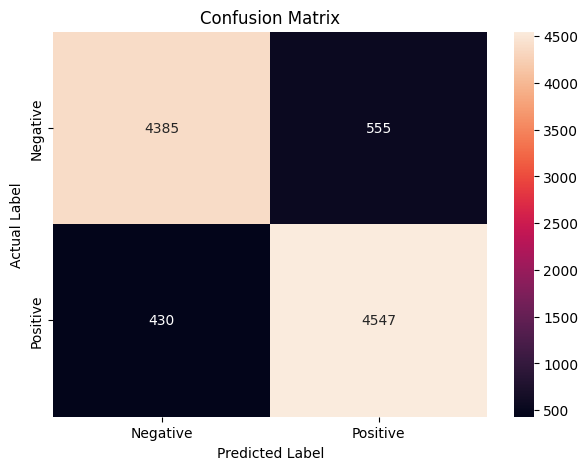

In [31]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

Create model performance graph

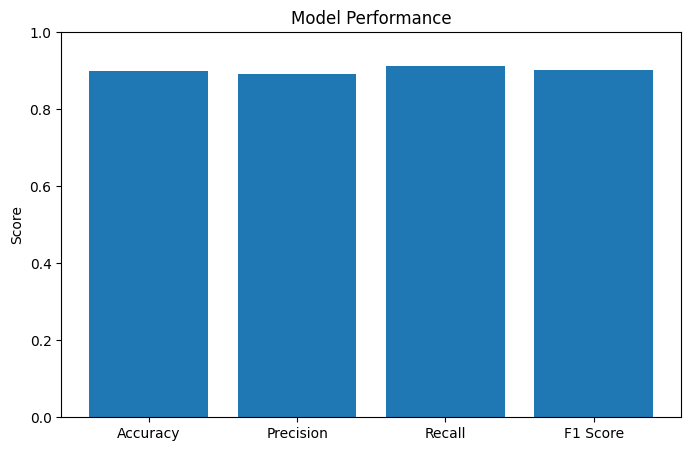

In [32]:
metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
}

plt.figure(figsize=(8, 5))

plt.bar(
    metrics.keys(),
    metrics.values()
)

plt.ylim(0, 1)
plt.title("Model Performance")
plt.ylabel("Score")

plt.show()

Understand Logistic Regression coefficients

In [33]:
feature_names = np.array(tfidf.get_feature_names_out())

coefficients = model.coef_[0]

print("Number of features:", len(feature_names))

Number of features: 50000


Find strongest positive words

In [34]:
positive_indices = np.argsort(coefficients)[-20:][::-1]

positive_words = pd.DataFrame({
    "Word/Phrase": feature_names[positive_indices],
    "Coefficient": coefficients[positive_indices]
})

positive_words

,Word/Phrase,Coefficient
0,great,7.855997
1,excellent,7.369203
2,perfect,5.890569
3,amazing,5.366053
4,wonderful,5.229530
5,best,5.117359
6,loved,4.752126
7,one best,4.686971
8,brilliant,4.607220
9,favorite,4.599500


Find strongest negative words

In [35]:
negative_indices = np.argsort(coefficients)[:20]

negative_words = pd.DataFrame({
    "Word/Phrase": feature_names[negative_indices],
    "Coefficient": coefficients[negative_indices]
})

negative_words

,Word/Phrase,Coefficient
0,worst,-9.960759
1,bad,-8.524540
2,awful,-8.296482
3,boring,-7.342627
4,waste,-6.900135
5,poor,-6.614149
6,terrible,-6.384920
7,nothing,-5.974930
8,horrible,-5.199541
9,dull,-5.087631


Visualize important positive words

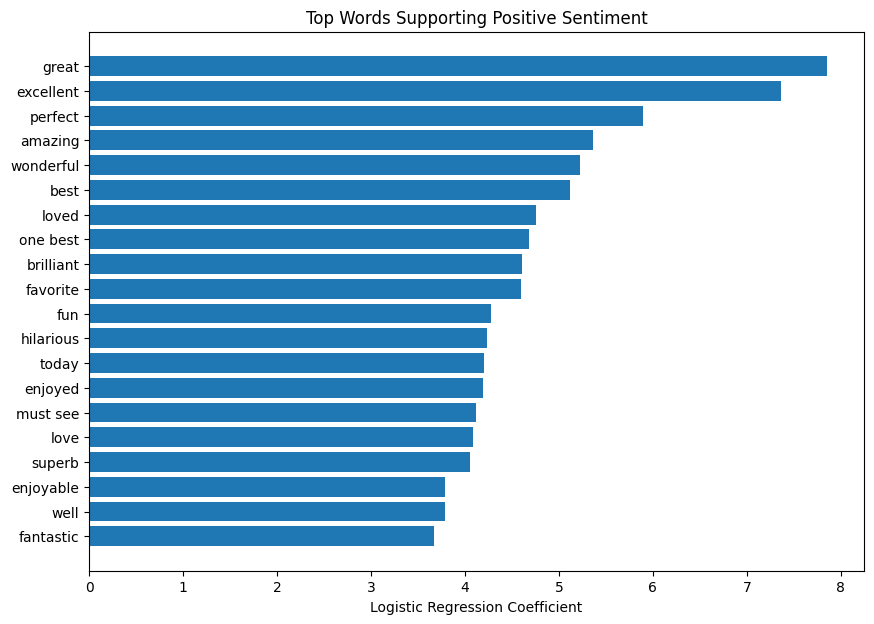

In [36]:
plt.figure(figsize=(10, 7))

plt.barh(
    positive_words["Word/Phrase"][::-1],
    positive_words["Coefficient"][::-1]
)

plt.title("Top Words Supporting Positive Sentiment")
plt.xlabel("Logistic Regression Coefficient")

plt.show()

Visualize important negative words

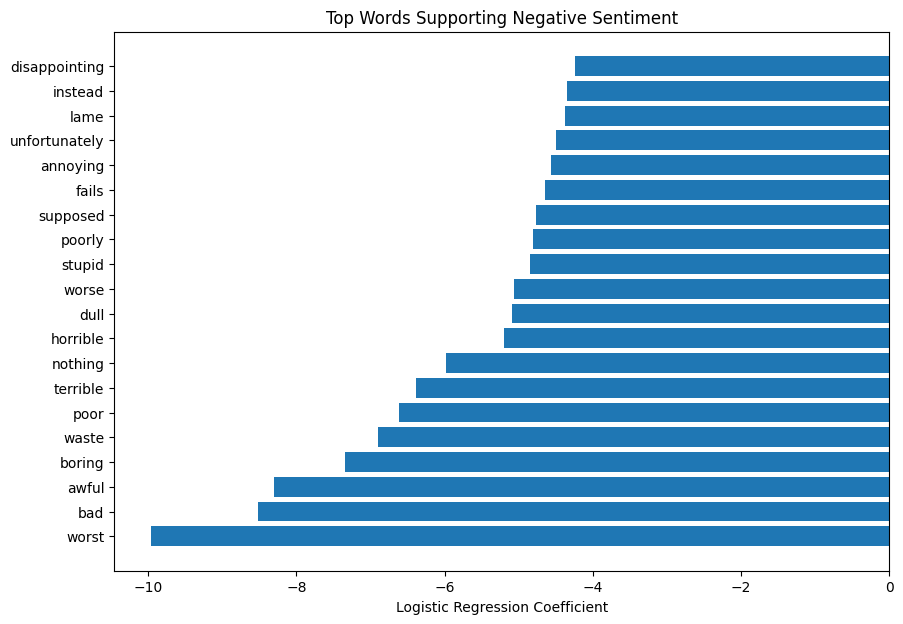

In [37]:
plt.figure(figsize=(10, 7))

plt.barh(
    negative_words["Word/Phrase"],
    negative_words["Coefficient"]
)

plt.title("Top Words Supporting Negative Sentiment")
plt.xlabel("Logistic Regression Coefficient")

plt.show()

Create explainable prediction function

In [38]:
def explain_prediction(text, top_n=10):

    # Clean the input
    cleaned = clean_text(text)

    # Convert to TF-IDF
    vector = tfidf.transform([cleaned])

    # Prediction
    prediction = model.predict(vector)[0]

    # Probability
    probabilities = model.predict_proba(vector)[0]

    negative_probability = probabilities[0]
    positive_probability = probabilities[1]

    # Get feature indices present in the review
    feature_indices = vector.nonzero()[1]

    explanations = []

    for index in feature_indices:

        word = feature_names[index]

        tfidf_value = vector[0, index]

        coefficient = coefficients[index]

        contribution = tfidf_value * coefficient

        explanations.append(
            (word, contribution)
        )

    # Sort by absolute contribution
    explanations = sorted(
        explanations,
        key=lambda x: abs(x[1]),
        reverse=True
    )

    top_explanations = explanations[:top_n]

    positive_words = [
        (word, score)
        for word, score in top_explanations
        if score > 0
    ]

    negative_words = [
        (word, score)
        for word, score in top_explanations
        if score < 0
    ]

    return {
        "prediction": "Positive" if prediction == 1 else "Negative",
        "positive_probability": positive_probability,
        "negative_probability": negative_probability,
        "positive_words": positive_words,
        "negative_words": negative_words
    }

Test explainable prediction

In [39]:
review = """
This movie was absolutely amazing.
The acting was excellent and the story was beautiful.
"""

result = explain_prediction(review)

print("Prediction:", result["prediction"])

print(
    "Positive Probability:",
    round(result["positive_probability"] * 100, 2),
    "%"
)

print(
    "Negative Probability:",
    round(result["negative_probability"] * 100, 2),
    "%"
)

print("\nWords supporting Positive sentiment:")

for word, score in result["positive_words"]:
    print(word, "->", round(score, 4))

print("\nWords supporting Negative sentiment:")

for word, score in result["negative_words"]:
    print(word, "->", round(score, 4))

Prediction: Positive
Positive Probability: 94.29 %
Negative Probability: 5.71 %

Words supporting Positive sentiment:
excellent -> 1.2695
amazing -> 1.0525
beautiful -> 0.4998
excellent story -> 0.1154
story -> 0.0862
absolutely amazing -> 0.0552
story beautiful -> 0.043

Words supporting Negative sentiment:
acting -> -0.261
movie -> -0.1138
absolutely -> -0.0932


Test a negative review

In [40]:
review = """
This movie was extremely boring and disappointing.
The acting was terrible and the story was very weak.
"""

result = explain_prediction(review)

print("Prediction:", result["prediction"])

print(
    "Positive Probability:",
    round(result["positive_probability"] * 100, 2),
    "%"
)

print(
    "Negative Probability:",
    round(result["negative_probability"] * 100, 2),
    "%"
)

print("\nWords supporting Positive sentiment:")

for word, score in result["positive_words"]:
    print(word, "->", round(score, 4))

print("\nWords supporting Negative sentiment:")

for word, score in result["negative_words"]:
    print(word, "->", round(score, 4))

Prediction: Negative
Positive Probability: 0.37 %
Negative Probability: 99.63 %

Words supporting Positive sentiment:

Words supporting Negative sentiment:
boring -> -1.3886
terrible -> -1.2471
disappointing -> -1.0884
weak -> -0.8206
acting -> -0.2748
acting terrible -> -0.1875
movie extremely -> -0.1686
extremely boring -> -0.1619
story weak -> -0.158
movie -> -0.1199


Create a cleaner explanation function

In [41]:
def predict_sentiment(text):

    result = explain_prediction(text, top_n=15)

    print("=" * 60)
    print("EXPLAINABLE SENTIMENT ANALYSIS")
    print("=" * 60)

    print("\nInput Review:")
    print(text)

    print("\nPredicted Sentiment:")
    print(result["prediction"])

    print("\nPositive Probability:")
    print(f"{result['positive_probability'] * 100:.2f}%")

    print("\nNegative Probability:")
    print(f"{result['negative_probability'] * 100:.2f}%")

    print("\nImportant Positive Words/Phrases:")

    if result["positive_words"]:
        for word, score in result["positive_words"]:
            print(f"  {word:<25} Contribution: {score:.4f}")
    else:
        print("  None")

    print("\nImportant Negative Words/Phrases:")

    if result["negative_words"]:
        for word, score in result["negative_words"]:
            print(f"  {word:<25} Contribution: {score:.4f}")
    else:
        print("  None")

    print("=" * 60)

Test your own review

In [42]:
predict_sentiment(
    "I really enjoyed this movie. The performances were excellent and the story was fantastic."
)

EXPLAINABLE SENTIMENT ANALYSIS

Input Review:
I really enjoyed this movie. The performances were excellent and the story was fantastic.

Predicted Sentiment:
Positive

Positive Probability:
98.65%

Negative Probability:
1.35%

Important Positive Words/Phrases:
  excellent                 Contribution: 1.3054
  enjoyed                   Contribution: 0.8446
  fantastic                 Contribution: 0.8249
  performance               Contribution: 0.4352
  enjoyed movie             Contribution: 0.4181
  really enjoyed            Contribution: 0.3113
  excellent story           Contribution: 0.1187
  story                     Contribution: 0.0886
  performance excellent     Contribution: 0.0166
  story fantastic           Contribution: 0.0127

Important Negative Words/Phrases:
  movie                     Contribution: -0.1171
  movie performance         Contribution: -0.0425
  really                    Contribution: -0.0392


In [43]:
predict_sentiment(
    "The movie was terrible. The story was boring and the acting was disappointing."
)

EXPLAINABLE SENTIMENT ANALYSIS

Input Review:
The movie was terrible. The story was boring and the acting was disappointing.

Predicted Sentiment:
Negative

Positive Probability:
0.32%

Negative Probability:
99.68%

Important Positive Words/Phrases:
  story                     Contribution: 0.1151

Important Negative Words/Phrases:
  boring                    Contribution: -1.7618
  terrible                  Contribution: -1.5823
  disappointing             Contribution: -1.3809
  movie terrible            Contribution: -0.4928
  acting                    Contribution: -0.3486
  story boring              Contribution: -0.1661
  movie                     Contribution: -0.1521
  terrible story            Contribution: -0.1014


Create a visual explanation

In [44]:
def plot_explanation(text, top_n=10):

    result = explain_prediction(text, top_n=top_n)

    words = []
    scores = []

    for word, score in result["positive_words"]:
        words.append(word)
        scores.append(score)

    for word, score in result["negative_words"]:
        words.append(word)
        scores.append(score)

    if not words:
        print("No important words found.")
        return

    explanation_df = pd.DataFrame({
        "Word": words,
        "Contribution": scores
    })

    explanation_df = explanation_df.sort_values(
        "Contribution"
    )

    plt.figure(figsize=(10, 6))

    plt.barh(
        explanation_df["Word"],
        explanation_df["Contribution"]
    )

    plt.axvline(
        0,
        linestyle="--"
    )

    plt.title(
        f"Word Contributions - Predicted {result['prediction']} Sentiment"
    )

    plt.xlabel(
        "Contribution to Prediction"
    )

    plt.show()

Save the model

In [45]:
import joblib

joblib.dump(model, "sentiment_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model and TF-IDF vectorizer saved successfully!")

Model and TF-IDF vectorizer saved successfully!


Check saved files

In [46]:
import os

print(os.listdir("."))

['.config', 'sentiment_model.pkl', 'tfidf_vectorizer.pkl', 'sample_data']


Load the saved model

In [47]:
loaded_model = joblib.load("sentiment_model.pkl")
loaded_tfidf = joblib.load("tfidf_vectorizer.pkl")

print("Saved model loaded successfully!")

Saved model loaded successfully!


Test loaded model

In [48]:
test_review = """
The movie was fantastic and I really enjoyed every moment.
"""

cleaned_test = clean_text(test_review)

test_vector = loaded_tfidf.transform([cleaned_test])

prediction = loaded_model.predict(test_vector)[0]

if prediction == 1:
    print("Prediction: Positive")
else:
    print("Prediction: Negative")

Prediction: Positive


Create a final prediction function

In [49]:
def final_prediction(text):

    cleaned_text = clean_text(text)

    vector = tfidf.transform([cleaned_text])

    prediction = model.predict(vector)[0]

    probabilities = model.predict_proba(vector)[0]

    if prediction == 1:
        sentiment = "Positive"
    else:
        sentiment = "Negative"

    confidence = probabilities[prediction] * 100

    return sentiment, confidence

Test final function

In [50]:
sentiment, confidence = final_prediction(
    "This was one of the best movies I have ever watched!"
)

print("Sentiment:", sentiment)
print("Confidence:", round(confidence, 2), "%")

Sentiment: Positive
Confidence: 97.32 %


Create Gradio interface

In [51]:
import gradio as gr

Create Gradio prediction function

In [52]:
def gradio_predict(text):

    if not text or text.strip() == "":
        return "Please enter a movie review.", ""

    result = explain_prediction(text, top_n=10)

    sentiment = result["prediction"]

    if sentiment == "Positive":
        confidence = result["positive_probability"] * 100
    else:
        confidence = result["negative_probability"] * 100

    explanation = []

    explanation.append(
        f"Prediction: {sentiment}"
    )

    explanation.append(
        f"Confidence: {confidence:.2f}%"
    )

    explanation.append(
        "\nWords supporting the prediction:"
    )

    all_words = (
        result["positive_words"] +
        result["negative_words"]
    )

    all_words = sorted(
        all_words,
        key=lambda x: abs(x[1]),
        reverse=True
    )

    for word, score in all_words:
        direction = "Positive" if score > 0 else "Negative"

        explanation.append(
            f"{word} → {direction} ({score:.4f})"
        )

    return sentiment, "\n".join(explanation)

Create the interface

In [53]:
demo = gr.Interface(
    fn=gradio_predict,
    inputs=gr.Textbox(
        lines=6,
        placeholder="Enter a movie review here..."
    ),
    outputs=[
        gr.Textbox(label="Predicted Sentiment"),
        gr.Textbox(label="Explanation")
    ],
    title="Explainable NLP Sentiment Analysis",
    description=(
        "Enter a movie review to predict its sentiment "
        "and see which words influenced the prediction."
    )
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://83bb86435f97fd40bf.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


This movie was fantastic. The acting was excellent and the story was beautiful.

This movie was terrible. It was boring and disappointing.


Create a final model summary

In [54]:
print("=" * 60)
print("EXPLAINABLE NLP SENTIMENT ANALYSIS")
print("=" * 60)

print("\nDataset")
print("IMDb Movie Reviews")

print("\nNumber of samples")
print(len(df))

print("\nFeature Extraction")
print("TF-IDF")

print("\nClassification Algorithm")
print("Logistic Regression")

print("\nAccuracy")
print(f"{accuracy * 100:.2f}%")

print("\nPrecision")
print(f"{precision * 100:.2f}%")

print("\nRecall")
print(f"{recall * 100:.2f}%")

print("\nF1 Score")
print(f"{f1 * 100:.2f}%")

print("\nExplainability")
print("TF-IDF word/phrase contribution using Logistic Regression coefficients")

print("=" * 60)

EXPLAINABLE NLP SENTIMENT ANALYSIS

Dataset
IMDb Movie Reviews

Number of samples
49582

Feature Extraction
TF-IDF

Classification Algorithm
Logistic Regression

Accuracy
90.07%

Precision
89.12%

Recall
91.36%

F1 Score
90.23%

Explainability
TF-IDF word/phrase contribution using Logistic Regression coefficients


Save the important results

In [55]:
results_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

results_df.to_csv(
    "model_performance.csv",
    index=False
)

print("Performance results saved!")

Performance results saved!


Save important words

In [56]:
positive_words.to_csv(
    "important_positive_words.csv",
    index=False
)

negative_words.to_csv(
    "important_negative_words.csv",
    index=False
)

print("Important word lists saved!")

Important word lists saved!


Download your project files

In [57]:
from google.colab import files

files.download("sentiment_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

To download the files in my system
files.download("tfidf_vectorizer.pkl")
files.download("model_performance.csv")
files.download("important_positive_words.csv")
files.download("important_negative_words.csv")